# Análisis de Patrones Temporales y EDA (Exploratory Data Analysis)

Este notebook aborda la **Issue #17**. El objetivo es entender los patrones de contaminación en Liverpool (PM2.5 y PM10) utilizando el dataset estandarizado (`sensors_definitivo.csv`). Analizaremos los datos en diferentes resoluciones temporales (horaria, diaria, semanal y estacional) para identificar picos y regularidades.

## Objetivos
1. **Resampling Temporal**: Agregar los datos a medias horarias, diarias y mensuales.
2. **Análisis Ciclo Diario**: Identificar picos (correlación con *rush hours*).
3. **Análisis Semanal**: Días laborables vs. fines de semana.
4. **Análisis Estacional**: Variaciones entre meses.
5. **Outliers Temporales**: Eventos extremos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Asegurar carpeta de outputs
os.makedirs('../../outputs/figures/eda', exist_ok=True)

# Cargar dataset definitivo
df = pd.read_csv('../../data/processed/sensors_definitivo.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Extraer componentes temporales para análisis ágil
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek # 0=Lunes, 6=Domingo
df['is_weekend'] = df['day_of_week'] >= 5
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['date'] = df['datetime'].dt.date

print(f"Dataset cargado: {len(df):,} registros")
print(f"Periodo: {df['datetime'].min()} al {df['datetime'].max()}")
df.head()


Dataset cargado: 1,537,060 registros
Periodo: 2021-03-20 07:30:00 al 2025-04-01 11:30:00


,datetime,sensor_id,Temperature,Humidity,PM1.0,PM2.5,PM10,lat,lon,label,tipo,hour,day_of_week,is_weekend,month,year,date
0,2021-10-28 05:00:00,f008d1cc04ec,19.030000,61.175000,1.409908,4.452372,14.182025,-2.98279,53.4397,Kirkdale station,valido,5,3,False,10,2021,2021-10-28
1,2021-10-28 05:30:00,f008d1cc04ec,19.019615,61.237173,1.398274,4.407409,14.075734,-2.98279,53.4397,Kirkdale station,valido,5,3,False,10,2021,2021-10-28
2,2021-10-28 06:00:00,f008d1cc04ec,19.009231,61.299346,1.386641,4.362447,13.969443,-2.98279,53.4397,Kirkdale station,valido,6,3,False,10,2021,2021-10-28
3,2021-10-28 06:30:00,f008d1cc04ec,18.998846,61.361519,1.375008,4.317484,13.863152,-2.98279,53.4397,Kirkdale station,valido,6,3,False,10,2021,2021-10-28
4,2021-10-28 07:00:00,f008d1cc04ec,18.988462,61.423692,1.363375,4.272522,13.756861,-2.98279,53.4397,Kirkdale station,valido,7,3,False,10,2021,2021-10-28


## 1. Evolución Temporal (Time Series Plot)

Vamos a agregar los datos a nivel de toda la ciudad (promediando todos los sensores) por semana y mes para ver las tendencias generales de $PM_{2.5}$ y $PM_{10}$ a lo largo de los años.

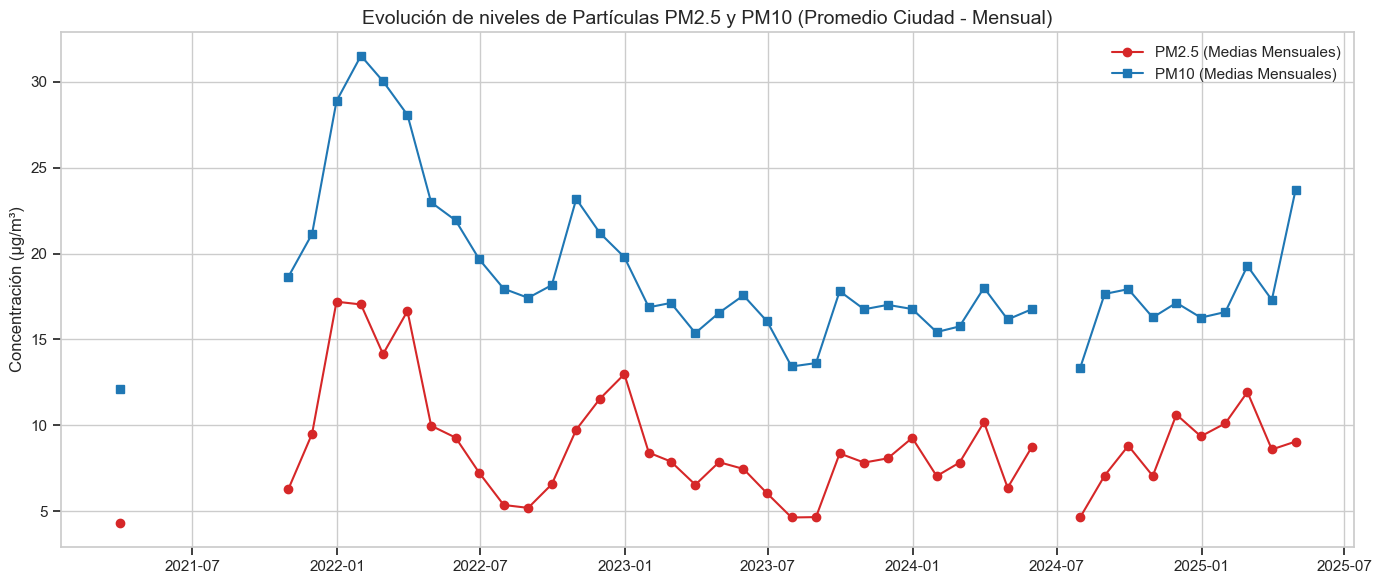

In [2]:
# Promedio de toda la ciudad
city_avg = df.groupby('datetime')[['PM2.5', 'PM10']].mean().reset_index()

# Remuestreo mensual
city_monthly = city_avg.set_index('datetime').resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(city_monthly.index, city_monthly['PM2.5'], label='PM2.5 (Medias Mensuales)', color='#d62728', marker='o')
ax.plot(city_monthly.index, city_monthly['PM10'], label='PM10 (Medias Mensuales)', color='#1f77b4', marker='s')

ax.set_title("Evolución de niveles de Partículas PM2.5 y PM10 (Promedio Ciudad - Mensual)", fontsize=14)
ax.set_ylabel("Concentración (µg/m³)")
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/ts_monthly_pollution.png')
plt.show()


## 2. Análisis del Ciclo Diario (Rush Hours)

El tráfico es uno de los mayores emisores locales. Veamos la concentración media de partículas en cada hora del día para identificar las horas punta (*rush hours*).

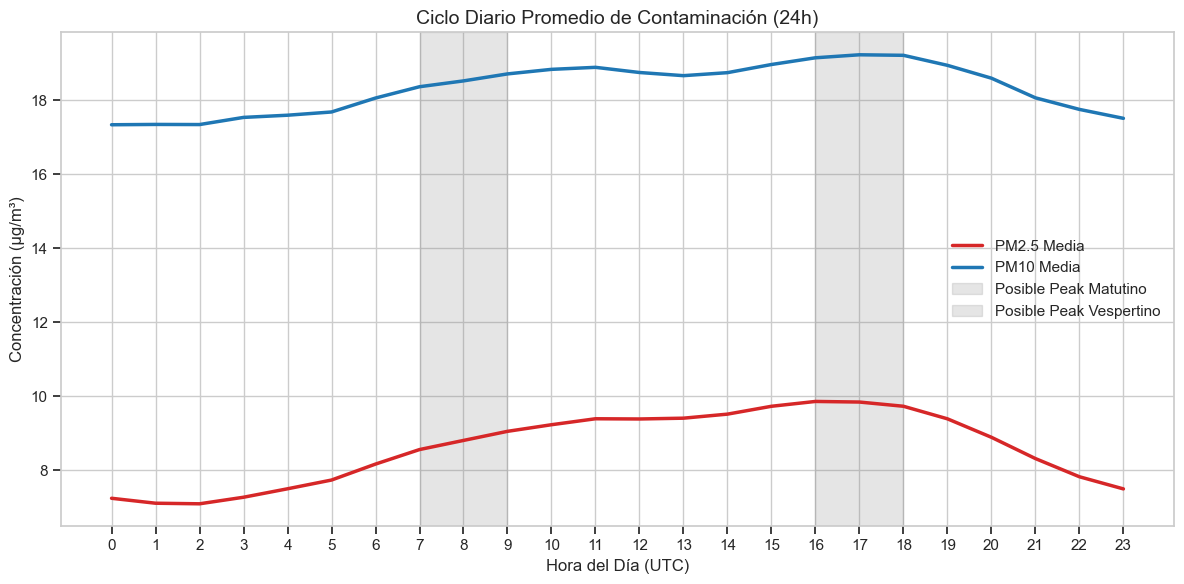

In [3]:
# Agrupar por hora
hourly_avg = df.groupby('hour')[['PM2.5', 'PM10', 'Temperature']].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_avg['hour'], hourly_avg['PM2.5'], label='PM2.5 Media', color='#d62728', linewidth=2.5)
ax.plot(hourly_avg['hour'], hourly_avg['PM10'], label='PM10 Media', color='#1f77b4', linewidth=2.5)

# Zonas de tráfico (aprox. 7-9 y 16-18)
ax.axvspan(7, 9, color='gray', alpha=0.2, label='Posible Peak Matutino')
ax.axvspan(16, 18, color='gray', alpha=0.2, label='Posible Peak Vespertino')

ax.set_xticks(range(0, 24))
ax.set_title("Ciclo Diario Promedio de Contaminación (24h)", fontsize=14)
ax.set_xlabel("Hora del Día (UTC)")
ax.set_ylabel("Concentración (µg/m³)")
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/hourly_cycle.png')
plt.show()


## 3. Análisis Semanal (Laborable vs Fin de Semana) y Boxplots

¿Se nota el descenso del tráfico los fines de semana? Haremos un modelo de Día de la Semana y un mapa de calor (*heatmap* de Calendario) cruzando Día de la Semana con Hora del Día.

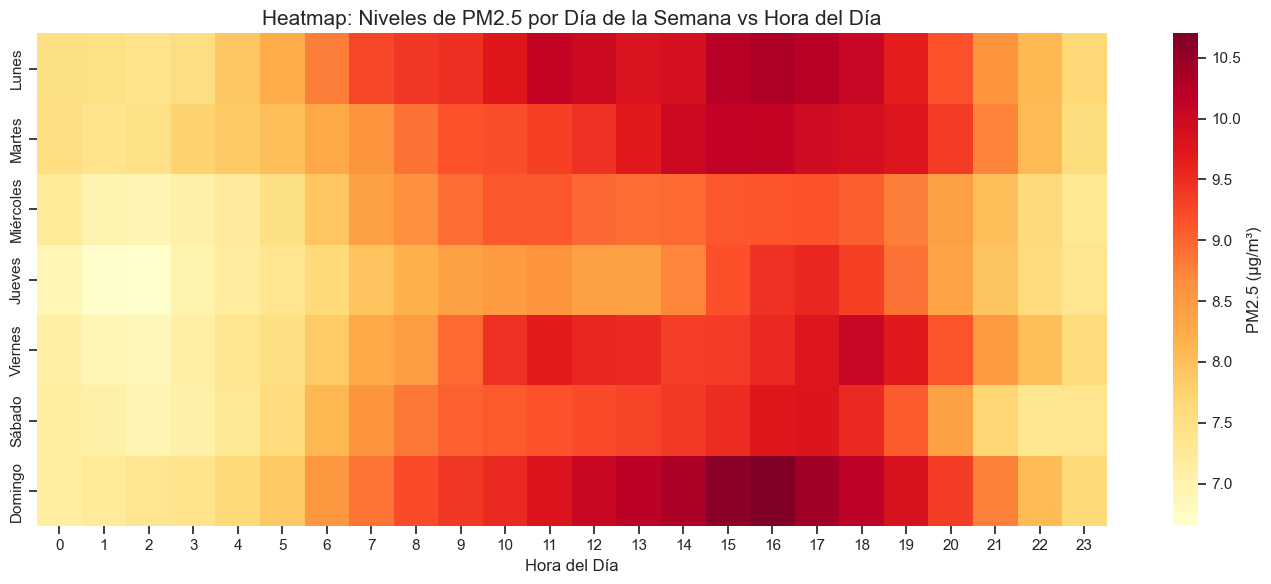

In [4]:
# Matriz: día de la semana vs hora
weekly_hourly = df.groupby(['day_of_week', 'hour'])['PM2.5'].mean().reset_index()
heatmap_data = weekly_hourly.pivot_table(index='day_of_week', columns='hour', values='PM2.5')

# Etiquetas de días (0=Lunes... 6=Domingo)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
heatmap_data.index = dias

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt=".1f", cbar_kws={'label': 'PM2.5 (µg/m³)'})
plt.title("Heatmap: Niveles de PM2.5 por Día de la Semana vs Hora del Día", fontsize=15)
plt.xlabel("Hora del Día")
plt.ylabel("")
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/heatmap_week_hour.png')
plt.show()


## 4. Variación Estacional (Boxplots Mensuales)

Distribución completa por meses, observaremos si el invierno (uso de calefacción, inversiones térmicas) genera mayores concentraciones que el verano.

C:\Users\Ivan\AppData\Local\Temp\ipykernel_34684\1782994860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PM2.5', palette='viridis', showfliers=False)


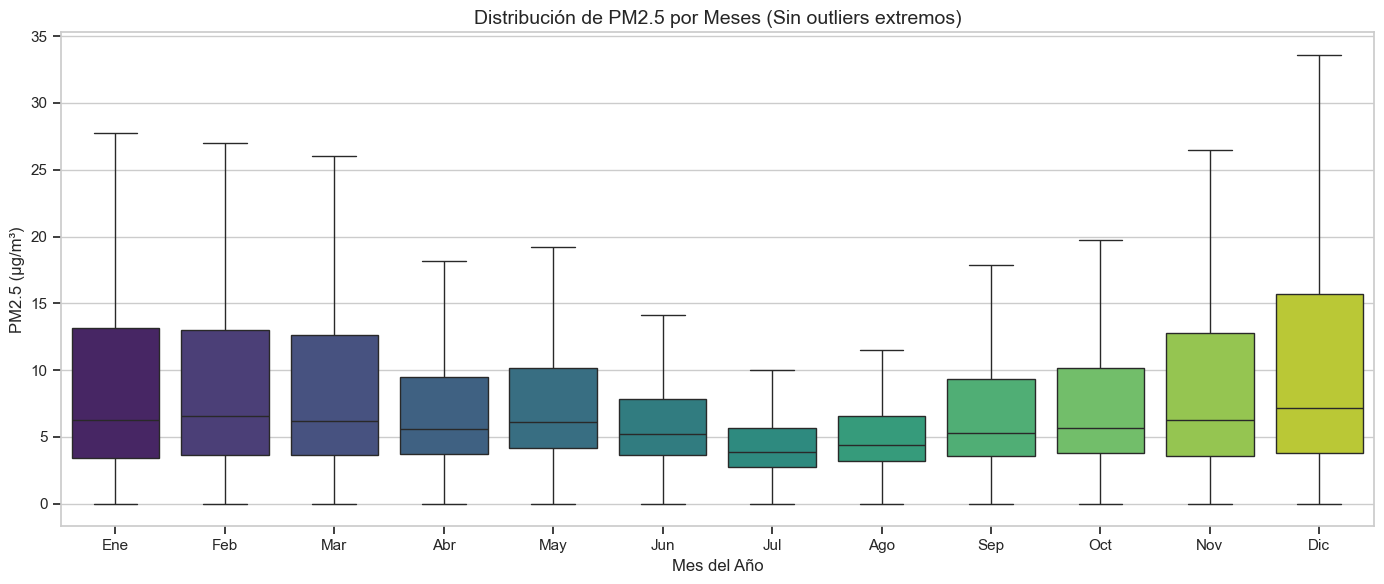

In [5]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='month', y='PM2.5', palette='viridis', showfliers=False)
plt.title("Distribución de PM2.5 por Meses (Sin outliers extremos)", fontsize=14)
plt.xlabel("Mes del Año")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(12), meses)
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/boxplot_monthly.png')
plt.show()


## 5. Detección de Outliers Extremos o Anomalías (Eventos)

Veamos el **Top 10** de días más contaminados registrados a nivel ciudad, para buscar explicación (ej. Guy Fawkes Night, incendios, calima severa).

In [6]:
# Promedio global por días
daily_pollution = df.groupby('date')['PM2.5'].mean().reset_index()
top_10 = daily_pollution.sort_values(by='PM2.5', ascending=False).head(10)

print("Top 10 Días más contaminados a nivel de ciudad (Liverpool, PM2.5):")
display(top_10)

fig = px.line(daily_pollution, x='date', y='PM2.5', title='Media Diaria de PM2.5 con Outliers (Interactiva)')
fig.add_hline(y=15, line_dash='dash', line_color='red', annotation_text="Límite OMS 24h")
fig.show()


Top 10 Días más contaminados a nivel de ciudad (Liverpool, PM2.5):


,date,PM2.5
1378,2024-12-27,38.823370
311,2022-01-25,37.628574
278,2021-12-23,37.363139
622,2022-12-02,36.202731
282,2021-12-27,34.935325
275,2021-12-20,32.300851
368,2022-03-23,31.756716
348,2022-03-03,30.748030
371,2022-03-26,30.264093
633,2022-12-13,29.692640


In [7]:
# Añade esto después de crear daily_pollution
daily_pollution['PM2.5_smooth'] = daily_pollution['PM2.5'].rolling(window=7, center=True).mean()

# En el gráfico, usa la columna suavizada
fig = px.line(daily_pollution, x='date', y='PM2.5_smooth', title='Tendencia Suavizada (Media Móvil 7 días)')
fig.show()


---
## 6. EDA Espacial para el Modelo LUR

Esta sección analiza los **20 sensores** que alimentan el modelo LUR sensor-level:
concentraciones medias anuales (2024), distribución espacial y relación entre
las variables OSMnx (features) y la contaminación.

> **Fuentes**: `data/interim/lur_features.csv` · `data/interim/sensores_2024_agregados.csv`
> · `data/interim/sensores_snapped_summary.csv`


In [8]:
import warnings, os
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as ctx
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

ROOT    = Path("../..").resolve()
FIG_DIR = ROOT / "outputs" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

feat    = pd.read_csv(ROOT / "data/interim/lur_features.csv")
s2024   = pd.read_csv(ROOT / "data/interim/sensores_2024_agregados.csv")
snapped = pd.read_csv(ROOT / "data/interim/sensores_snapped_summary.csv")

df_raw  = pd.read_csv(ROOT / "data/processed/sensors_definitivo.csv",
                      usecols=["sensor_id", "label"])
labels  = df_raw.drop_duplicates("sensor_id").set_index("sensor_id")["label"]

snapped["label"] = snapped["sensor_id"].map(labels)
s2024["label"]   = s2024["sensor_id"].map(labels)
dropped = s2024[~s2024["sensor_id"].isin(snapped["sensor_id"])].copy()
dropped["label"] = dropped["sensor_id"].map(labels)

print(f"Sensores totales (2024, >75% completitud): {len(s2024)}")
print(f"Sensores snapped (en modelo LUR):          {len(snapped)}")
print(f"Sensores excluidos (snap >500m):            {len(dropped)}")


Sensores totales (2024, >75% completitud): 24
Sensores snapped (en modelo LUR):          20
Sensores excluidos (snap >500m):            4


### 6.1 Concentración media anual de PM por sensor

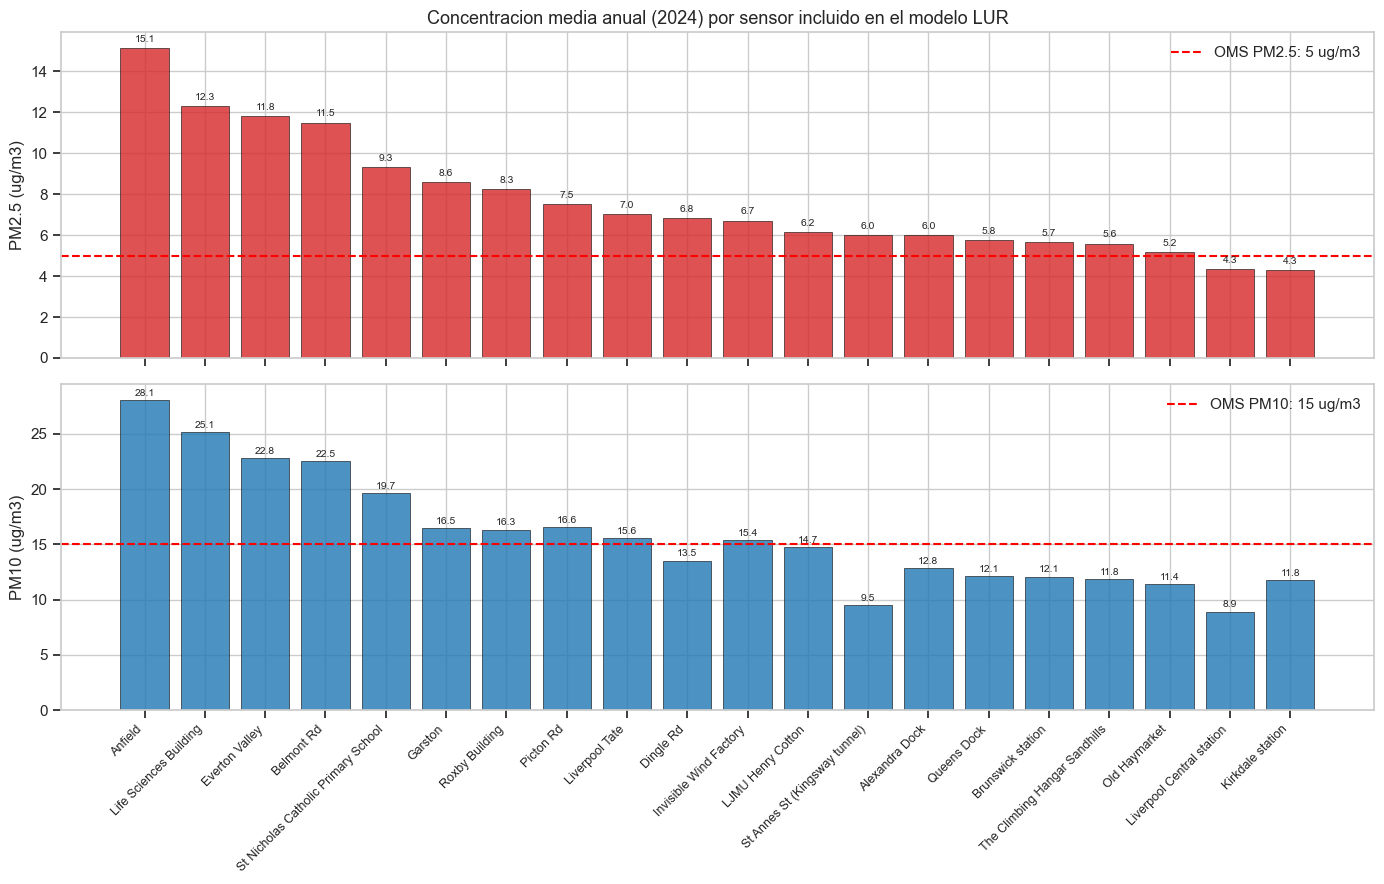

Rango PM2.5: 4.3 - 15.15 ug/m3
Rango PM10:  8.91 - 28.08 ug/m3


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
oms_limits = {"PM2.5": 5, "PM10": 15}
colors     = {"PM2.5": "#d62728", "PM10": "#1f77b4"}

for ax, col in zip(axes, ["PM2.5", "PM10"]):
    data = snapped.sort_values(col, ascending=False)
    bars = ax.bar(data["label"], data[col],
                  color=colors[col], alpha=0.8, edgecolor="k", linewidth=0.5)
    ax.axhline(oms_limits[col], color="red", ls="--", lw=1.5,
               label=f"OMS {col}: {oms_limits[col]} ug/m3")
    ax.set_ylabel(f"{col} (ug/m3)")
    ax.legend()
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.1f}", ha="center", va="bottom", fontsize=7.5)

axes[1].set_xticklabels(data["label"], rotation=45, ha="right", fontsize=9)
axes[0].set_title("Concentracion media anual (2024) por sensor incluido en el modelo LUR",
                  fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_pm_por_sensor.png", dpi=150, bbox_inches="tight")
plt.show()

print("Rango PM2.5:", round(snapped["PM2.5"].min(), 2), "-", round(snapped["PM2.5"].max(), 2), "ug/m3")
print("Rango PM10: ", round(snapped["PM10"].min(), 2), "-", round(snapped["PM10"].max(), 2), "ug/m3")


### 6.2 Distribución espacial de sensores y concentraciones PM2.5

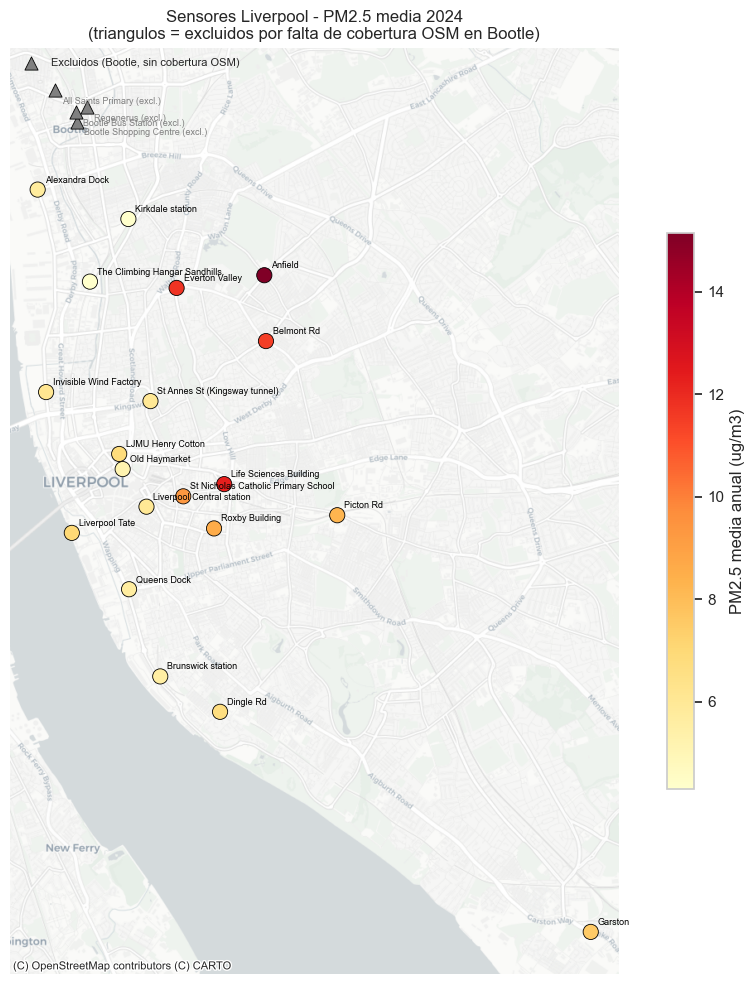

In [10]:
# NOTA: en sensors_definitivo.csv, columna "lat" contiene longitud (~-3) y "lon" latitud (~53)
gdf_snap = gpd.GeoDataFrame(
    snapped,
    geometry=gpd.points_from_xy(snapped["lat"], snapped["lon"]),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

gdf_drop = gpd.GeoDataFrame(
    dropped,
    geometry=gpd.points_from_xy(dropped["lat"], dropped["lon"]),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(10, 10))

gdf_snap.plot(
    ax=ax, column="PM2.5", cmap="YlOrRd",
    markersize=120, edgecolors="k", linewidths=0.6,
    legend=True,
    legend_kwds={"label": "PM2.5 media anual (ug/m3)", "shrink": 0.6}
)
gdf_drop.plot(ax=ax, color="gray", marker="^", markersize=90,
              edgecolors="k", linewidths=0.6,
              label="Excluidos (Bootle, sin cobertura OSM)")

for _, row in gdf_snap.iterrows():
    ax.annotate(row["label"],
                xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords="offset points",
                fontsize=6.5, color="black")
for _, row in gdf_drop.iterrows():
    ax.annotate(row["label"] + " (excl.)",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(5, -10), textcoords="offset points",
                fontsize=6.5, color="gray")

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
except Exception as e:
    print(f"Basemap no disponible: {e}")

ax.set_title("Sensores Liverpool - PM2.5 media 2024\n"
             "(triangulos = excluidos por falta de cobertura OSM en Bootle)", fontsize=12)
ax.legend(loc="upper left", fontsize=8)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_mapa_sensores.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Sensores excluidos del modelo LUR

Los 4 sensores siguientes pasaron el filtro de completitud (>75%) pero fueron descartados
en el paso de *snapping* porque la red viaria OSM (`streets_liverpool.gpkg`) no cubre
el municipio de **Bootle** (norte de Liverpool).

> **Impacto**: se pierde información en la zona norte/industrial de Liverpool.
> El modelo puede subestimar la contaminación en esa área al predecir.


In [11]:
print("Sensores excluidos (Bootle - fuera de cobertura OSM):")
print(dropped[["label", "lat", "lon", "PM2.5", "PM10"]].to_string(index=False))

pm_in  = snapped[["PM2.5", "PM10"]].mean()
pm_out = dropped[["PM2.5", "PM10"]].mean()
print(f"\nMedia PM sensores incluidos:  PM2.5={pm_in['PM2.5']:.2f}  PM10={pm_in['PM10']:.2f}")
print(f"Media PM sensores excluidos:  PM2.5={pm_out['PM2.5']:.2f}  PM10={pm_out['PM10']:.2f}")
print()
print("All Saints Primary (PM2.5=12.1) y Bootle Bus Station estan excluidos a pesar de")
print("ser sensores potencialmente importantes para capturar gradientes norte-sur.")


Sensores excluidos (Bootle - fuera de cobertura OSM):
                 label       lat       lon     PM2.5      PM10
             Regenerus -2.991470 53.453550  7.605740 17.713256
    All Saints Primary -2.997960 53.455650 12.146112 26.206095
Bootle Shopping Centre -2.993371 53.451742  7.136743 15.311029
    Bootle Bus Station -2.993633 53.452963  6.811103 15.189583

Media PM sensores incluidos:  PM2.5=7.70  PM10=15.87
Media PM sensores excluidos:  PM2.5=8.42  PM10=18.60

All Saints Primary (PM2.5=12.1) y Bootle Bus Station estan excluidos a pesar de
ser sensores potencialmente importantes para capturar gradientes norte-sur.


### 6.4 Relacion features OSM vs PM2.5 (buffer 500 m)

Scatter de cada variable LUR frente a PM2.5 en el buffer de 500 m.
El coeficiente de correlacion de Pearson (r) aparece en el titulo de cada panel.


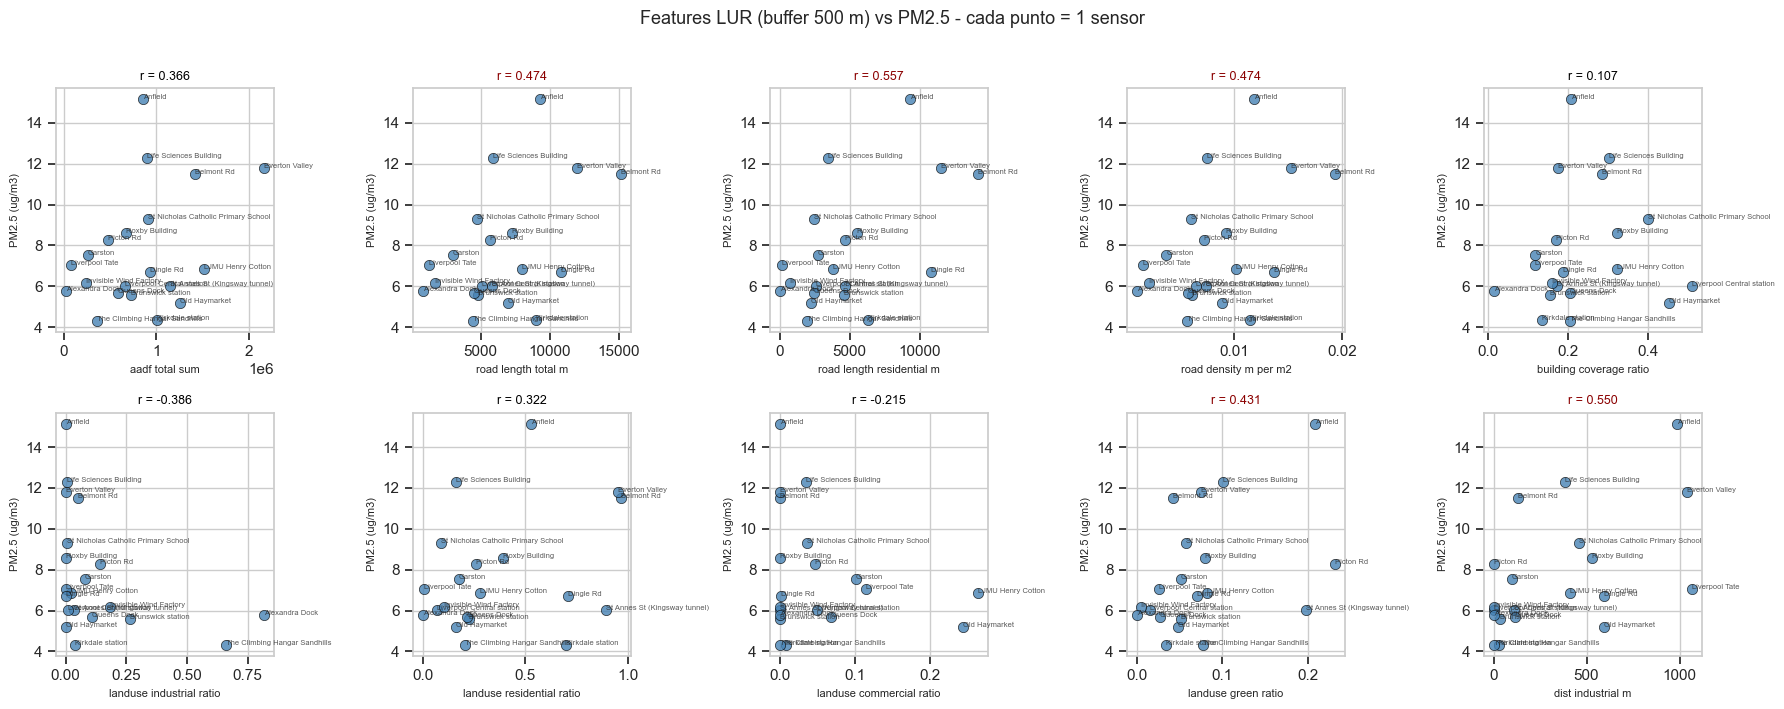

In [12]:
feat_500 = feat[feat["buffer_m"] == 500].copy()
feat_500["label"] = feat_500["sensor_id"].map(labels)

FEATURE_COLS = [
    "aadf_total_sum", "road_length_total_m", "road_length_residential_m",
    "road_density_m_per_m2", "building_coverage_ratio",
    "landuse_industrial_ratio", "landuse_residential_ratio",
    "landuse_commercial_ratio", "landuse_green_ratio", "dist_industrial_m",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in feat_500.columns]

ncols = 5
nrows = int(np.ceil(len(FEATURE_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.scatter(feat_500[col], feat_500["PM2.5"],
               color="steelblue", edgecolors="k", linewidths=0.5, s=55, alpha=0.8)
    corr = feat_500[[col, "PM2.5"]].corr().iloc[0, 1]
    for _, row in feat_500.iterrows():
        ax.annotate(row["label"], (row[col], row["PM2.5"]),
                    fontsize=5.5, alpha=0.75, ha="left")
    ax.set_xlabel(col.replace("_", " "), fontsize=8)
    ax.set_ylabel("PM2.5 (ug/m3)", fontsize=8)
    ax.set_title(f"r = {corr:.3f}", fontsize=9,
                 color="darkred" if abs(corr) > 0.4 else "black")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Features LUR (buffer 500 m) vs PM2.5 - cada punto = 1 sensor",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_scatter_features_pm25.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.5 Anomalia: `landuse_green_ratio` tiene correlacion POSITIVA con PM2.5

Se esperaria que la cobertura verde reduzca la contaminacion, pero el modelo detecta
lo contrario (r > 0). Este analisis examina en que escala aparece y que sensores
lo generan.

**Hipotesis**: en buffers pequenos (100 m), los parques urbanos grandes (ej. Stanley Park
junto a Anfield) tienen alta cobertura verde OSM pero estan rodeados de calles
con trafico elevado. La verde no reduce la PM a escala local de 100 m.


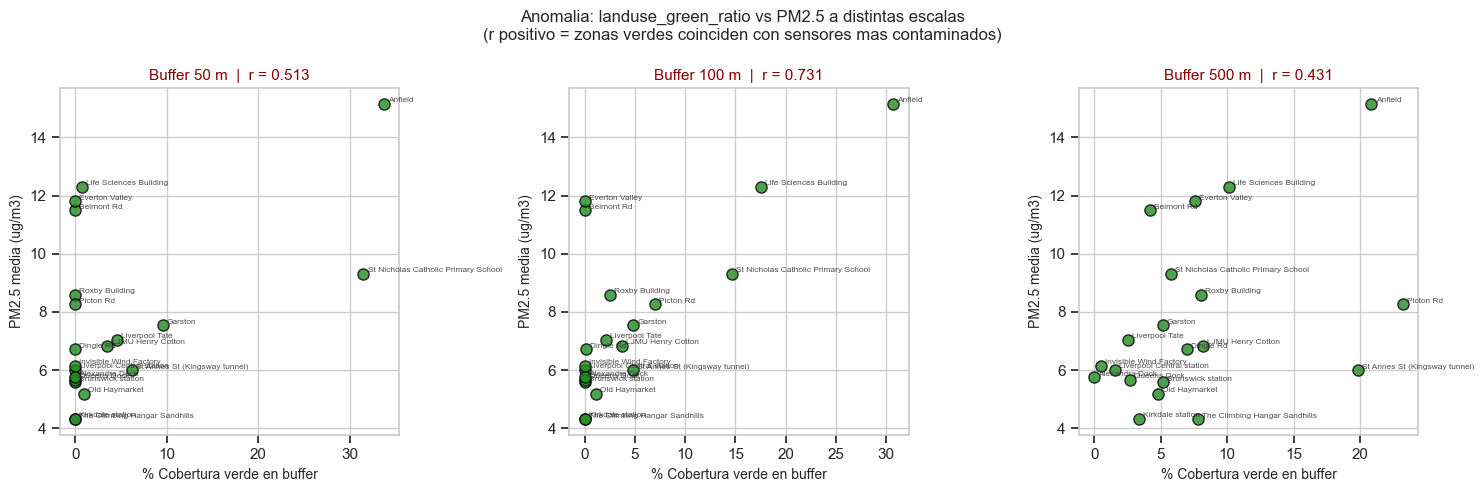

Top 5 sensores con mayor cobertura verde (buffer 100 m):
                              label  pct_verde  dist_industrial_m     PM2.5      PM10
                            Anfield       30.7         987.003807 15.148609 28.076828
             Life Sciences Building       17.5         383.500688 12.303161 25.145719
St Nicholas Catholic Primary School       14.6         457.229870  9.312037 19.663364
                          Picton Rd        7.0           1.311598  8.260367 16.345660
                            Garston        4.9          99.119725  7.538344 16.600609

Conclusion: Anfield (junto a Stanley Park) lidera en cobertura verde
pero es el sensor mas contaminado (PM2.5=15.1). La asociacion positiva
es un artefacto espacial, no una relacion causal.
Recomendacion para el PLS: considerar excluir o transformar esta variable.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, buf in zip(axes, [50, 100, 500]):
    sub = feat[feat["buffer_m"] == buf].copy()
    sub["label"] = sub["sensor_id"].map(labels)
    corr = sub[["landuse_green_ratio", "PM2.5"]].corr().iloc[0, 1]

    ax.scatter(sub["landuse_green_ratio"] * 100, sub["PM2.5"],
               color="forestgreen", edgecolors="k", s=65, alpha=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row["label"],
                    (row["landuse_green_ratio"] * 100, row["PM2.5"]),
                    fontsize=6, alpha=0.8, ha="left",
                    xytext=(3, 1), textcoords="offset points")
    ax.set_xlabel("% Cobertura verde en buffer", fontsize=10)
    ax.set_ylabel("PM2.5 media (ug/m3)", fontsize=10)
    ax.set_title(f"Buffer {buf} m  |  r = {corr:.3f}", fontsize=11,
                 color="darkred" if corr > 0.4 else "black")

fig.suptitle("Anomalia: landuse_green_ratio vs PM2.5 a distintas escalas\n"
             "(r positivo = zonas verdes coinciden con sensores mas contaminados)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_anomalia_greenratio.png", dpi=150, bbox_inches="tight")
plt.show()

feat_100 = feat[feat["buffer_m"] == 100].copy()
feat_100["label"] = feat_100["sensor_id"].map(labels)
top_green = feat_100.nlargest(5, "landuse_green_ratio")[
    ["label", "landuse_green_ratio", "dist_industrial_m", "PM2.5", "PM10"]
].copy()
top_green["pct_verde"] = (top_green["landuse_green_ratio"] * 100).round(1)
print("Top 5 sensores con mayor cobertura verde (buffer 100 m):")
print(top_green[["label","pct_verde","dist_industrial_m","PM2.5","PM10"]].to_string(index=False))
print()
print("Conclusion: Anfield (junto a Stanley Park) lidera en cobertura verde")
print("pero es el sensor mas contaminado (PM2.5=15.1). La asociacion positiva")
print("es un artefacto espacial, no una relacion causal.")
print("Recomendacion para el PLS: considerar excluir o transformar esta variable.")


### 6.6 Matriz de correlacion entre features LUR (buffer 500 m)

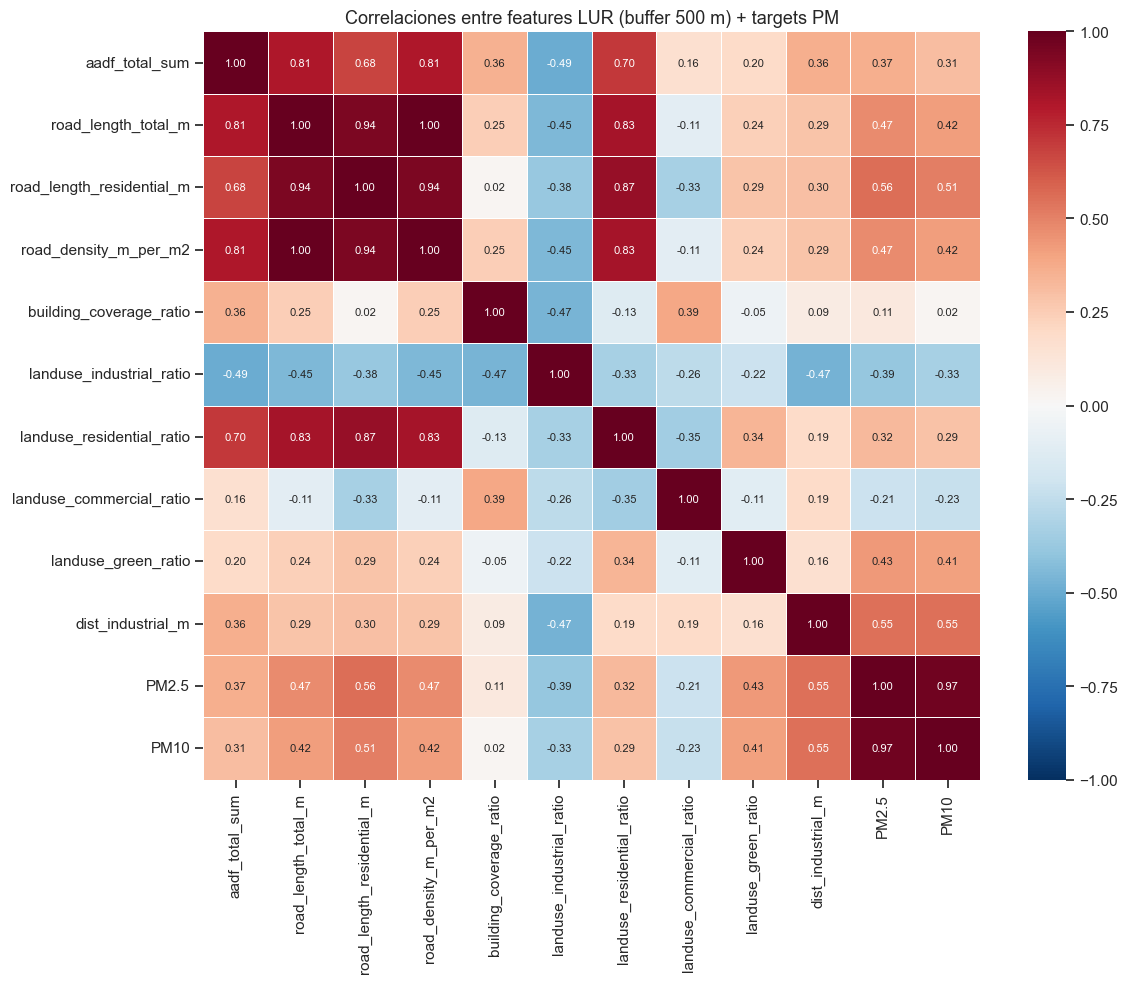

Pares con |r| > 0.80 (multicolinealidad severa, problematicos para OLS):
  aadf_total_sum                           <-> road_length_total_m                       r=0.807
  aadf_total_sum                           <-> road_density_m_per_m2                     r=0.807
  road_length_total_m                      <-> road_length_residential_m                 r=0.943
  road_length_total_m                      <-> road_density_m_per_m2                     r=1.000
  road_length_total_m                      <-> landuse_residential_ratio                 r=0.834
  road_length_residential_m                <-> road_density_m_per_m2                     r=0.943
  road_length_residential_m                <-> landuse_residential_ratio                 r=0.873
  road_density_m_per_m2                    <-> landuse_residential_ratio                 r=0.834

Motivacion para PLS: colinealidad alta -> OLS inestable. PLS maneja esto por diseno.


In [14]:
feat_500_corr = feat[feat["buffer_m"] == 500][FEATURE_COLS + ["PM2.5", "PM10"]].copy()
corr_matrix   = feat_500_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Correlaciones entre features LUR (buffer 500 m) + targets PM", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_correlacion_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("Pares con |r| > 0.80 (multicolinealidad severa, problematicos para OLS):")
for i, ci in enumerate(FEATURE_COLS):
    for j, cj in enumerate(FEATURE_COLS):
        if j <= i:
            continue
        c = corr_matrix.loc[ci, cj]
        if abs(c) > 0.80:
            print(f"  {ci:40s} <-> {cj:40s}  r={c:.3f}")
print("\nMotivacion para PLS: colinealidad alta -> OLS inestable. PLS maneja esto por diseno.")


### 6.7 Varianza inter-sensor vs intra-sensor

Para que un LUR sea util, la **varianza espacial** (diferencias entre sensores)
debe ser relevante respecto a la varianza temporal. Si la varianza inter-sensor
es baja, los sensores son demasiado similares para entrenar el modelo.


Descomposicion de varianza:


  PM2.5:
    Varianza inter-sensor: 5.960 (8.6% del total)
    Varianza intra-sensor: 61.701 (89.5% del total)
    Rango medias:          4.93 - 14.58 ug/m3



  PM10:
    Varianza inter-sensor: 20.245 (15.7% del total)
    Varianza intra-sensor: 106.014 (82.4% del total)
    Rango medias:          12.56 - 28.57 ug/m3



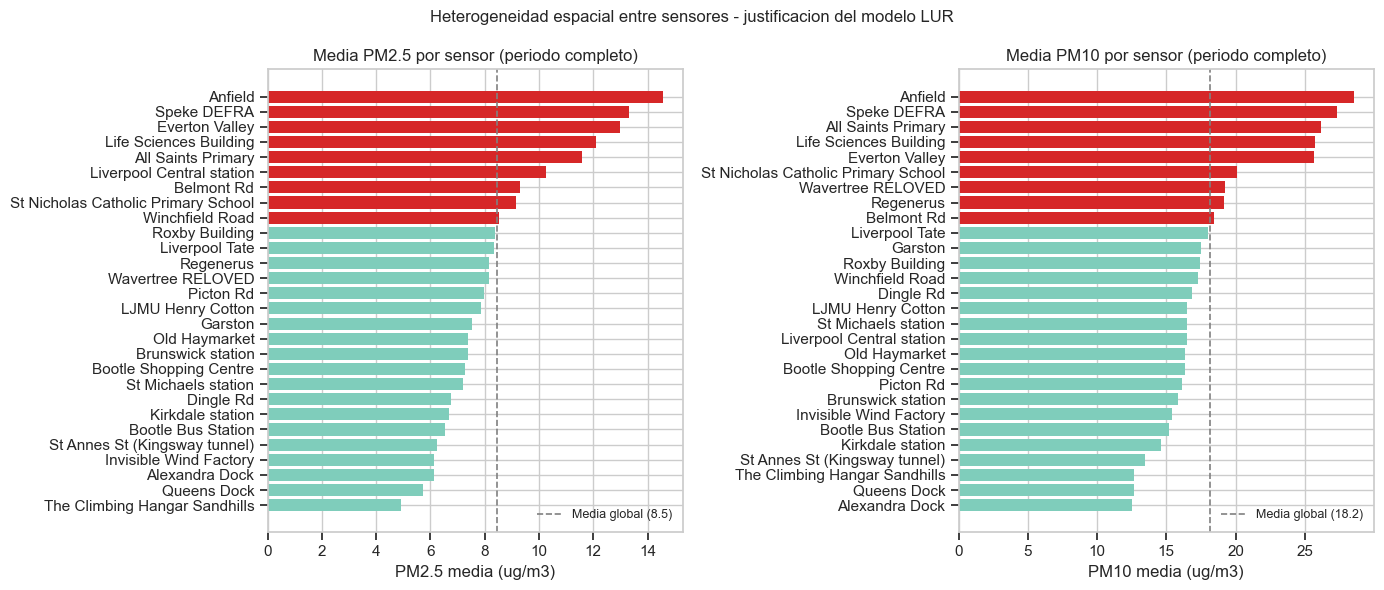

In [15]:
df_var = pd.read_csv(ROOT / "data/processed/sensors_definitivo.csv",
                     usecols=["sensor_id", "PM2.5", "PM10"], low_memory=False)
df_var = df_var[df_var["PM2.5"].notna() & df_var["PM10"].notna()]

print("Descomposicion de varianza:")
for target in ["PM2.5", "PM10"]:
    sensor_mean = df_var.groupby("sensor_id")[target].mean()
    var_total   = df_var[target].var()
    var_inter   = sensor_mean.var()
    var_intra   = df_var.groupby("sensor_id")[target].var().mean()
    print(f"  {target}:")
    print(f"    Varianza inter-sensor: {var_inter:.3f} ({100*var_inter/var_total:.1f}% del total)")
    print(f"    Varianza intra-sensor: {var_intra:.3f} ({100*var_intra/var_total:.1f}% del total)")
    print(f"    Rango medias:          {sensor_mean.min():.2f} - {sensor_mean.max():.2f} ug/m3")
    print()

# Boxplot medias por sensor
sensor_means_all = df_var.groupby("sensor_id")[["PM2.5","PM10"]].mean().reset_index()
sensor_means_all["label"] = sensor_means_all["sensor_id"].map(labels)
global_mean = sensor_means_all["PM2.5"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, ["PM2.5", "PM10"]):
    data  = sensor_means_all.sort_values(col)
    gm    = data[col].mean()
    color = ["#d62728" if v > gm else "#7fcdbb" for v in data[col]]
    ax.barh(data["label"], data[col], color=color)
    ax.axvline(gm, ls="--", color="gray", lw=1.2, label=f"Media global ({gm:.1f})")
    ax.set_xlabel(f"{col} media (ug/m3)")
    ax.set_title(f"Media {col} por sensor (periodo completo)")
    ax.legend(fontsize=9)

plt.suptitle("Heterogeneidad espacial entre sensores - justificacion del modelo LUR",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "lur_varianza_inter_sensor.png", dpi=150, bbox_inches="tight")
plt.show()
